<a id="sec-top"></a>
# 🛒 Rossmann Store Sales — Exploratory Data Analysis

**Project:** Rossmann Sales Forecasting
**Notebook:** `01_eda.ipynb`
**Data source:** [Rossmann Store Sales (Kaggle)](https://www.kaggle.com/c/rossmann-store-sales/data)
**Tables used:** `sales_daily` (from `train.csv`), `stores` (from `store.csv`)

Explore the Rossmann sales data to understand seasonality, promotion effects, store-level
differences, and data quality issues — before moving on to feature engineering and modeling.

**All queries below are executed against a SQLite/Postgres backend via SQLAlchemy, not loaded
directly from CSV.** This mirrors the same database layer the production FastAPI service will
query later, so the SQL written here is reusable, not throwaway exploration.

---

## 📑 Table of Contents
- [0. Setup](#sec-0)
- [1. Data Overview](#sec-1)
- [2. Data Quality Checks](#sec-2)
- [3. Target Variable (Sales) Analysis](#sec-3)
- [4. Time-Based Patterns](#sec-4)
- [5. Holiday Effect](#sec-5)
- [6. Promotions Analysis](#sec-6)
- [7. Store-Level Analysis](#sec-7)
- [8. Store Closures & Anomalies](#sec-8)
- [9. Feature Preview & Correlation](#sec-9)
- [10. Summary & Key Findings](#sec-10)

---

<a id="sec-0"></a>
## 0. Setup

Import libraries, connect to the database, and define a small helper function
(`run_query`) so every SQL query in this notebook can be run in one line and
returned directly as a pandas DataFrame.

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Nicer default look for all plots in this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
from sqlalchemy import create_engine

# Using local SQLite for fast, offline EDA iteration.
# In production (the deployed API), the same code points at Supabase Postgres
# instead — only the connection string changes, the SQL stays identical.
engine = create_engine("sqlite:///../data/processed/rossmann.db")

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SQL query string against `engine` and return the result as a DataFrame."""
    return pd.read_sql(query, engine)

### Quick preview of the raw data
Before running any aggregate queries, pull the first few rows just to confirm the
table looks as expected (correct columns, sensible values).

In [4]:
run_query("""
SELECT *
FROM sales_daily
LIMIT 5;
""")

,store_id,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday
0,1,5,2015-07-31 00:00:00.000000,5263,555,1,1,0,1
1,2,5,2015-07-31 00:00:00.000000,6064,625,1,1,0,1
2,3,5,2015-07-31 00:00:00.000000,8314,821,1,1,0,1
3,4,5,2015-07-31 00:00:00.000000,13995,1498,1,1,0,1
4,5,5,2015-07-31 00:00:00.000000,4822,559,1,1,0,1


Columns `store_id, day_of_week, date, sales, customers,
open, promo, state_holiday, school_holiday` confirm nothing looks off (e.g. dates
not parsed as dates, booleans stored oddly) before continuing.

---

<a id="sec-1"></a>
## 1. Data Overview

Establish the basic shape of the dataset: how many rows, how many stores, what date
range is covered, and whether there are any duplicate records.

### 1.1 Row counts

In [5]:
# Total number of daily sales records across all stores
run_query("""
SELECT COUNT(*) AS total_sales_rows
FROM sales_daily;
""")

,total_sales_rows
0,1017209


In [6]:
# Total number of stores in the metadata table
run_query("""
SELECT COUNT(*) AS total_stores
FROM stores;
""")

,total_stores
0,1115


### 1.2 Date range covered

In [7]:
# Earliest and latest date present in the sales data
run_query("""
SELECT
    DATE(MIN(date)) AS earliest_date,
    DATE(MAX(date)) AS latest_date
FROM sales_daily;
""")

,earliest_date,latest_date
0,2013-01-01,2015-07-31


This defines the full
history available for backtesting later, and how much "room" there is for a
train/validation/test split in the modeling notebooks.

### 1.3 Distinct stores represented in sales data

In [8]:
# Confirms every store in `stores` actually has sales records
run_query("""
SELECT COUNT(DISTINCT store_id) AS distinct_stores_in_sales
FROM sales_daily;
""")

,distinct_stores_in_sales
0,1115


### 1.4 Duplicate (store_id, date) check

In [9]:
# A store should have at most ONE row per date.
run_query("""
SELECT
    store_id,
    date,
    COUNT(*) AS cnt
FROM sales_daily
GROUP BY store_id, date
HAVING COUNT(*) > 1;
""")

,store_id,date,cnt


An empty result confirms no duplicate (store, date) pairs now it is safe
to treat `(store_id, date)` as a natural key going forward.


<a id="sec-2"></a>
## 2. Data Quality Checks

Look for missing values and logically inconsistent rows (e.g. a store marked "open"
with zero customers/sales, or "closed" with nonzero sales) — these need explicit
handling decisions before feature engineering.

### 2.1 Missing values in the `stores` table

In [10]:
# Counts NULLs per column. 
# CompetitionDistance/Month/Year are NULL when no competitor data was recorded,
# and Promo2SinceWeek/Year/PromoInterval are NULL when Promo2 = 0 (store never
# ran the long-running promotion) these aren't necessarily errors.
run_query("""
SELECT
    SUM(CASE WHEN competition_distance IS NULL THEN 1 ELSE 0 END) AS null_competition_distance,
    SUM(CASE WHEN competition_open_since_month IS NULL THEN 1 ELSE 0 END) AS null_comp_open_month,
    SUM(CASE WHEN competition_open_since_year IS NULL THEN 1 ELSE 0 END) AS null_comp_open_year,
    SUM(CASE WHEN promo2_since_week IS NULL THEN 1 ELSE 0 END) AS null_promo2_week,
    SUM(CASE WHEN promo2_since_year IS NULL THEN 1 ELSE 0 END) AS null_promo2_year,
    SUM(CASE WHEN promo_interval IS NULL THEN 1 ELSE 0 END) AS null_promo_interval
FROM stores;
""")

,null_competition_distance,null_comp_open_month,null_comp_open_year,null_promo2_week,null_promo2_year,null_promo_interval
0,3,354,354,544,544,544


The `promo2_*` and `promo_interval` null counts roughly
matches the number of stores with `promo2 = 0` which confirms the NULLs are structural,
not random missingness. `competition_distance` nulls (if any) are true missing
data and will need an imputation decision in feature engineering.

### 2.2 Open days with zero sales

In [11]:
# A store marked OPEN but recording zero sales is unusual 
# could be a data entry issue or a genuinely dead sales day.
run_query("""
SELECT COUNT(*) AS open_zero_sales
FROM sales_daily
WHERE open = 1 AND sales = 0;
""")

,open_zero_sales
0,54


### 2.3 Closed days with nonzero sales

In [12]:
# A store marked CLOSED should have zero sales.
run_query("""
SELECT COUNT(*) AS closed_nonzero_sales
FROM sales_daily
WHERE open = 0 AND sales > 0;
""")

,closed_nonzero_sales
0,0


📝 **Insight:** this should be 0 (or very close to it). Any nonzero result here
signals either a data entry error or a special case (e.g. partial-day trading)
that needs a documented handling decision.

### 2.4 Open vs. closed day distribution

In [13]:
open_closed = run_query("""
SELECT
    open,
    COUNT(*) AS n_rows
FROM sales_daily
GROUP BY open;
""")
open_closed

,open,n_rows
0,0,172817
1,1,844392


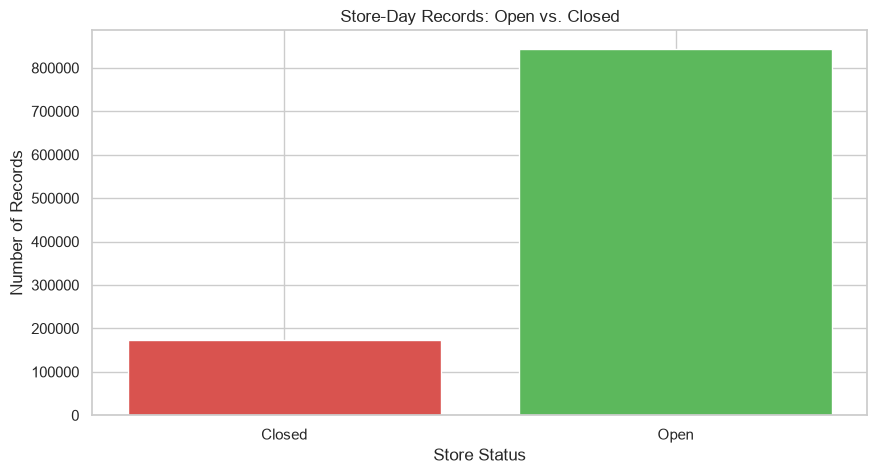

In [14]:
fig, ax = plt.subplots()
ax.bar(open_closed["open"].map({0: "Closed", 1: "Open"}), open_closed["n_rows"],
       color=["#d9534f", "#5cb85c"])
ax.set_title("Store-Day Records: Open vs. Closed")
ax.set_xlabel("Store Status")
ax.set_ylabel("Number of Records")
plt.show()

<a id="sec-3"></a>
## 3. Target Variable (Sales) Analysis

Understand the shape, scale, and relationships of `sales` the variable we'll
ultimately be forecasting.

### 3.1 Basic statistics on sales (open days only)

In [15]:
run_query("""
SELECT
    MIN(sales) AS min_sales,
    MAX(sales) AS max_sales,
    AVG(sales) AS avg_sales,
    COUNT(*) AS n_rows
FROM sales_daily
WHERE open = 1;
""")

,min_sales,max_sales,avg_sales,n_rows
0,0,41551,6955.514291,844392


A very high max relative to the
average often signals either a legitimate high-traffic day (holiday rush) or an
outlier.

### 3.2 Sales distribution

In [16]:
# Pull a sample of raw sales values (open days only) to visualize the distribution.
sales_sample = run_query("""
SELECT sales, customers
FROM sales_daily
WHERE open = 1
LIMIT 5000;
""")
sales_sample.head()

,sales,customers
0,5263,555
1,6064,625
2,8314,821
3,13995,1498
4,4822,559


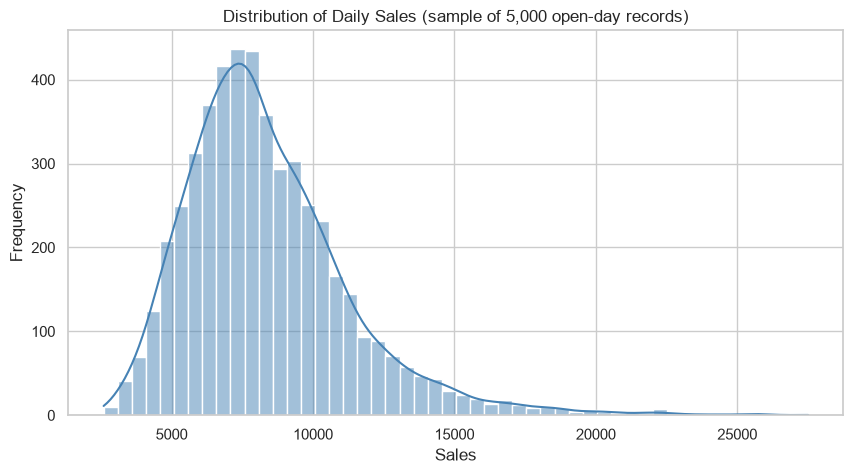

In [17]:
fig, ax = plt.subplots()
sns.histplot(sales_sample["sales"], bins=50, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Daily Sales (sample of 5,000 open-day records)")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")
plt.show()

Sales distribution is typically right-skewed (many normal days,
a long tail of high-sales days) this shapes modeling choices later (we can use log
transform which may help classical models like SARIMA).

### 3.3 Sales vs. Customers relationship

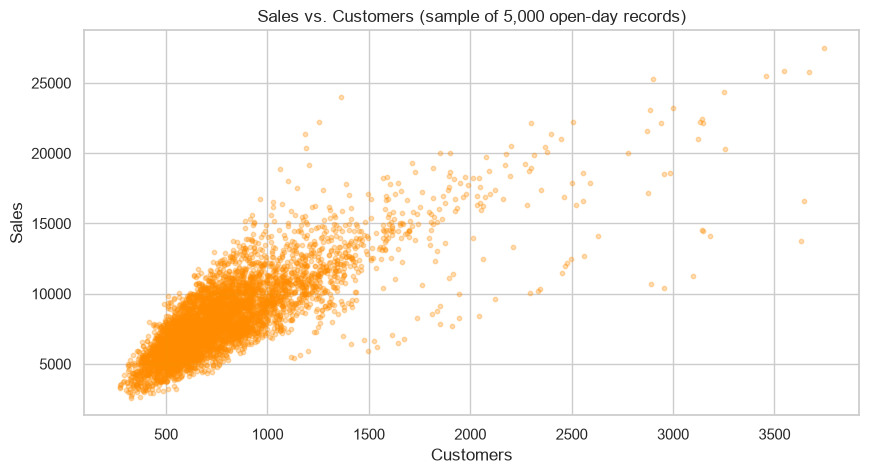

In [18]:
fig, ax = plt.subplots()
ax.scatter(sales_sample["customers"], sales_sample["sales"], alpha=0.3, s=10, color="darkorange")
ax.set_title("Sales vs. Customers (sample of 5,000 open-day records)")
ax.set_xlabel("Customers")
ax.set_ylabel("Sales")
plt.show()

A strong positive linear relationship as more customers
should mean more sales.

### 3.4 Average sales-per-customer

In [19]:
run_query("""
SELECT AVG(sales * 1.0 / NULLIF(customers, 0)) AS avg_sales_per_customer
FROM sales_daily
WHERE open = 1 AND customers > 0;
""")

,avg_sales_per_customer
0,9.493619


This gives a rough "average basket size" figure across all
stores which is useful later as a sanity check when comparing store-type segments.


<a id="sec-4"></a>
## 4. Time-Based Patterns

weekly/monthly seasonality, rolling
trends, and gaps in the time series.

### 4.1 Day-of-week seasonality

In [20]:
dow = run_query("""
SELECT
    day_of_week,
    AVG(sales) AS avg_sales,
    AVG(customers) AS avg_customers,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY day_of_week
ORDER BY day_of_week;
""")
dow

,day_of_week,avg_sales,avg_customers,n_days
0,1,8216.073074,855.444984,137560
1,2,7088.113656,769.986753,143961
2,3,6728.122978,740.598876,141936
3,4,6767.310159,755.569784,134644
4,5,7072.677012,781.771639,138640
5,6,5874.840238,660.177526,144058
6,7,8224.723908,1441.532424,3593


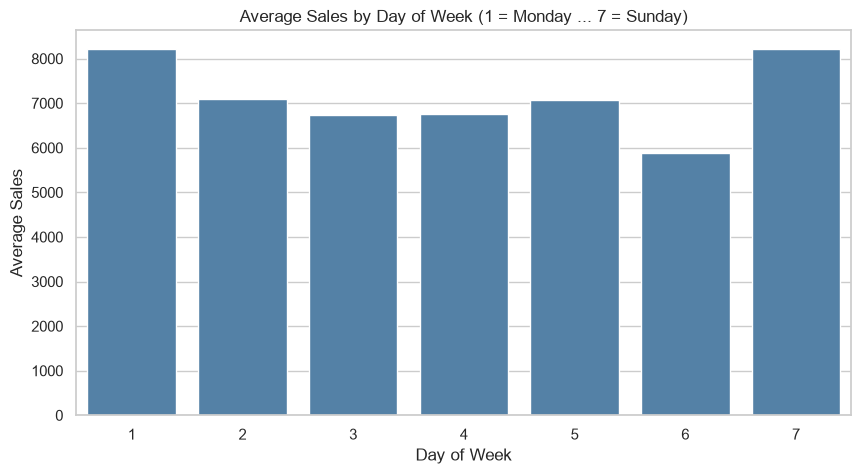

In [21]:
fig, ax = plt.subplots()
sns.barplot(data=dow, x="day_of_week", y="avg_sales", color="steelblue", ax=ax)
ax.set_title("Average Sales by Day of Week (1 = Monday ... 7 = Sunday)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Sales")
plt.show()

First and Last day of the week has higher avg sales compare to other days while Saturday has least sales.

### 4.2 Monthly / yearly trend

In [22]:
monthly = run_query("""
SELECT
    strftime('%Y', date) AS year,
    strftime('%m', date) AS month,
    AVG(sales) AS avg_sales,
    SUM(sales) AS total_sales
FROM sales_daily
WHERE open = 1
GROUP BY year, month
ORDER BY year, month;
""")
monthly.head()

,year,month,avg_sales,total_sales
0,2013,01,6239.641380,180132207
1,2013,02,6428.597796,171534275
2,2013,03,7212.834110,201180369
3,2013,04,6579.319656,183431432
4,2013,05,7076.217960,185411063


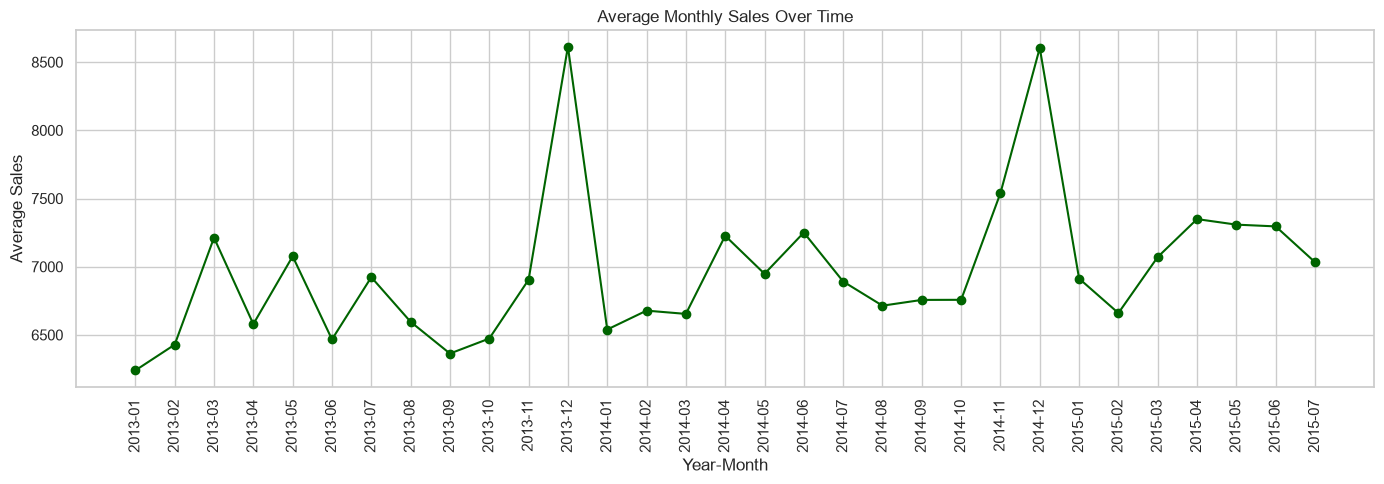

In [23]:
monthly["year_month"] = monthly["year"] + "-" + monthly["month"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["year_month"], monthly["avg_sales"], marker="o", color="darkgreen")
ax.set_title("Average Monthly Sales Over Time")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Average Sales")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

There we can cleary see 2 peaks in December month as December has holiday season, this tells us whether a trend
component is needed in the classical time-series models (SARIMA's "trend" term,
or an LSTM feature for month/season).

### 4.3 Rolling 7-day average sales (single store example)

In [24]:
rolling = run_query("""
SELECT
    DATE(date) AS date,
    store_id,
    sales,
    AVG(sales) OVER (
        PARTITION BY store_id
        ORDER BY date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) AS rolling_7day_avg
FROM sales_daily
WHERE store_id = 1 AND open = 1
ORDER BY date;
""")
rolling.head(10)

,date,store_id,sales,rolling_7day_avg
0,2013-01-02,1,5530,5530.000000
1,2013-01-03,1,4327,4928.500000
2,2013-01-04,1,4486,4781.000000
3,2013-01-05,1,4997,4835.000000
4,2013-01-07,1,7176,5303.200000
5,2013-01-08,1,5580,5349.333333
6,2013-01-09,1,5471,5366.714286
7,2013-01-10,1,4892,5275.571429
8,2013-01-11,1,4881,5354.714286
9,2013-01-12,1,4952,5421.285714


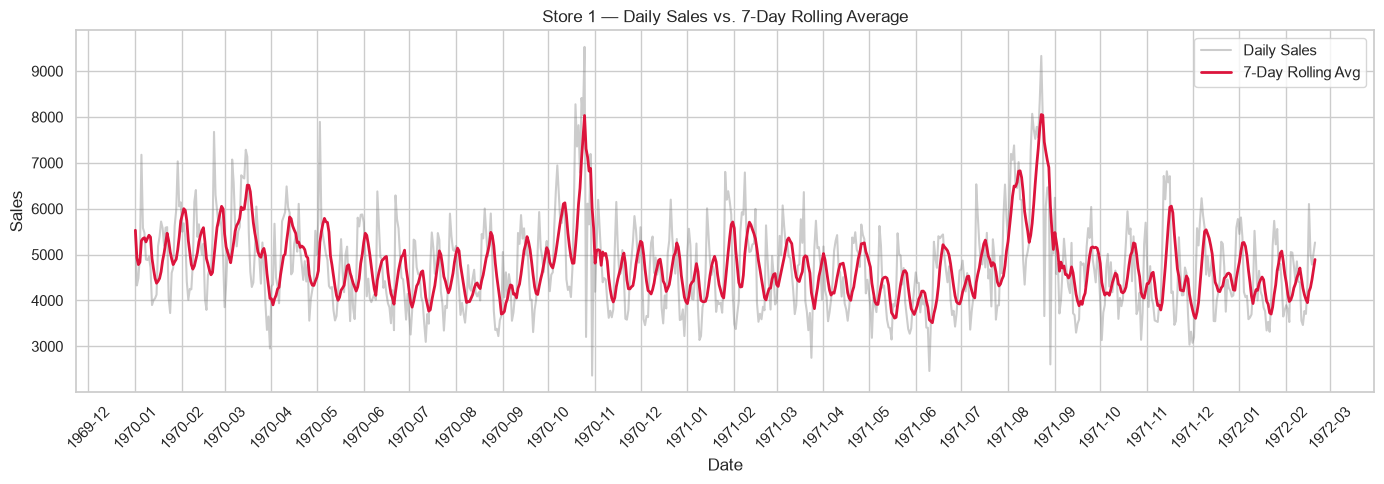

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling["date"], rolling["sales"], alpha=0.4, label="Daily Sales", color="gray")
ax.plot(rolling["date"], rolling["rolling_7day_avg"], label="7-Day Rolling Avg", color="crimson", linewidth=2)
ax.set_title("Store 1 — Daily Sales vs. 7-Day Rolling Average")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

# Show fewer dates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The rolling average smooths out day-to-day noise (e.g. weekday
dips) and exposes the underlying trend more clearly — exactly the kind of
feature that will feed into the LSTM as a lag/rolling input.

### 4.4 Day-over-day sales change

In [26]:
# LAG() pulls the previous row's value within the same partition (store),
# letting us compute a simple day-over-day delta.
dod = run_query("""
SELECT
    DATE(date) AS date,
    store_id,
    sales,
    LAG(sales, 1) OVER (PARTITION BY store_id ORDER BY date) AS prev_day_sales,
    sales - LAG(sales, 1) OVER (PARTITION BY store_id ORDER BY date) AS day_over_day_change
FROM sales_daily
WHERE store_id = 1 AND open = 1
ORDER BY date;
""")
dod.head(10)

,date,store_id,sales,prev_day_sales,day_over_day_change
0,2013-01-02,1,5530,NaN,NaN
1,2013-01-03,1,4327,5530.0,-1203.0
2,2013-01-04,1,4486,4327.0,159.0
3,2013-01-05,1,4997,4486.0,511.0
4,2013-01-07,1,7176,4997.0,2179.0
5,2013-01-08,1,5580,7176.0,-1596.0
6,2013-01-09,1,5471,5580.0,-109.0
7,2013-01-10,1,4892,5471.0,-579.0
8,2013-01-11,1,4881,4892.0,-11.0
9,2013-01-12,1,4952,4881.0,71.0


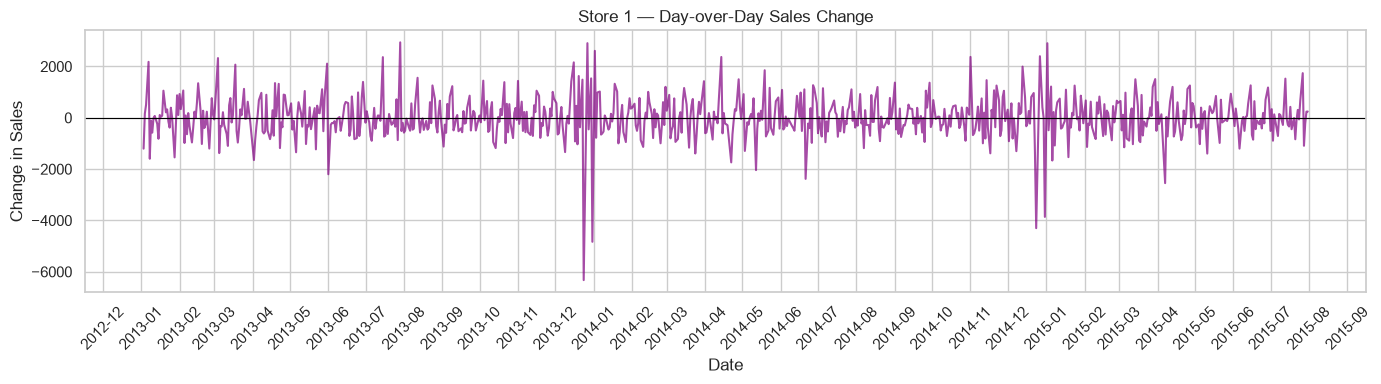

In [27]:
dod["date"] = pd.to_datetime(dod["date"]) # this is done so that MonthLocator can locate date

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dod["date"], dod["day_over_day_change"], color="purple", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Store 1 — Day-over-Day Sales Change")
ax.set_xlabel("Date")
ax.set_ylabel("Change in Sales")

# Show fewer dates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Large spikes here usually align with promo start/end dates or
holidays which cross-reference against the promo/holiday flags to confirm before
treating any spike as noise.

### 4.5 Single-store full time series

In [28]:
store1 = run_query("""
SELECT DATE(date) AS date, sales, customers, promo, state_holiday, school_holiday
FROM sales_daily
WHERE store_id = 1
ORDER BY date;
""")
store1.head()

,date,sales,customers,promo,state_holiday,school_holiday
0,2013-01-01,0,0,0,a,1
1,2013-01-02,5530,668,0,0,1
2,2013-01-03,4327,578,0,0,1
3,2013-01-04,4486,619,0,0,1
4,2013-01-05,4997,635,0,0,1


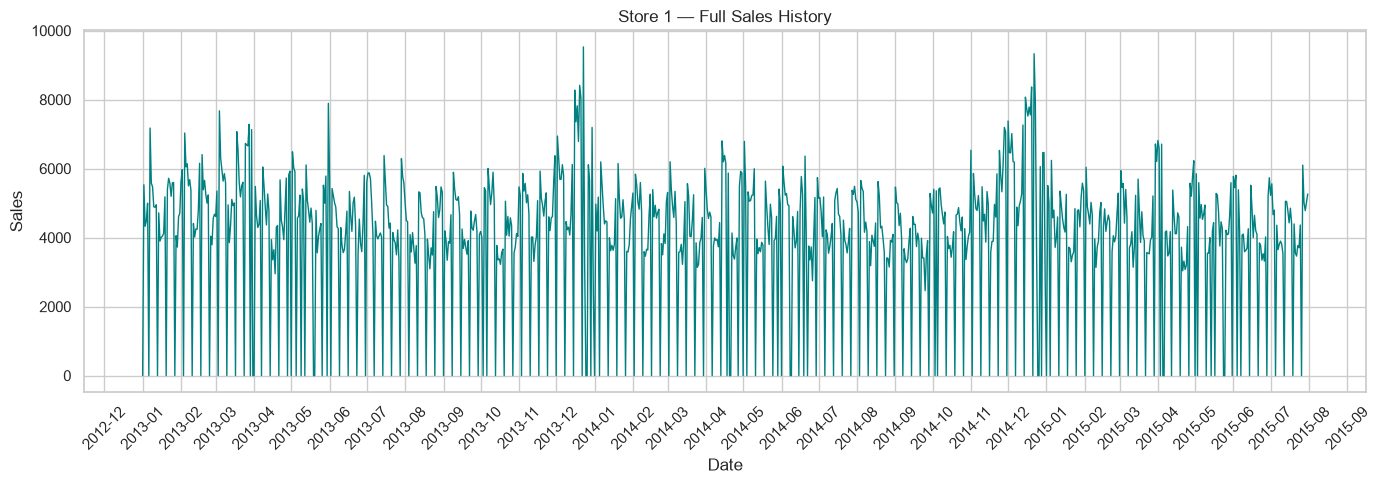

In [29]:
store1["date"] = pd.to_datetime(store1["date"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store1["date"], store1["sales"], color="teal", linewidth=1)
ax.set_title("Store 1 — Full Sales History")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visually confirm trend, seasonality, and any gaps (store closures
show up as drops to zero) for this individual store.

### 4.6 Missing dates per store

In [30]:
# Compares each store's recorded day count against the maximum possible
# (i.e. the number of distinct dates present anywhere in the dataset).
# A store with fewer recorded days than the max has gaps in its history.
missing_dates = run_query("""
SELECT
    store_id,
    COUNT(*) AS recorded_days,
    (SELECT COUNT(DISTINCT date) FROM sales_daily) AS total_possible_days
FROM sales_daily
GROUP BY store_id
HAVING COUNT(*) < (SELECT COUNT(DISTINCT date) FROM sales_daily)
ORDER BY recorded_days ASC;
""")
missing_dates

,store_id,recorded_days,total_possible_days
0,13,758,942
1,20,758,942
2,22,758,942
3,32,758,942
4,36,758,942
...,...,...,...
176,1102,758,942
177,1104,758,942
178,1107,758,942
179,1109,758,942


📝 **Insight:** any store listed here has fewer records than the full date range
likely opened partway through the data window, or has missing entries. Decide
whether to exclude these stores from per-store SARIMA models or handle the gap
explicitly (e.g. forward-fill flags, not sales values).

<a id="sec-5"></a>
## 5. Holiday Effect

Quantify how state and school holidays affect average sales.

### 5.1 State holiday effect

In [31]:
state_hol = run_query("""
SELECT
    state_holiday,
    AVG(sales) AS avg_sales,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY state_holiday
ORDER BY avg_sales DESC;
""")
state_hol

,state_holiday,avg_sales,n_days
0,b,9887.889655,145
1,c,9743.746479,71
2,a,8487.471182,694
3,0,6953.515034,843482


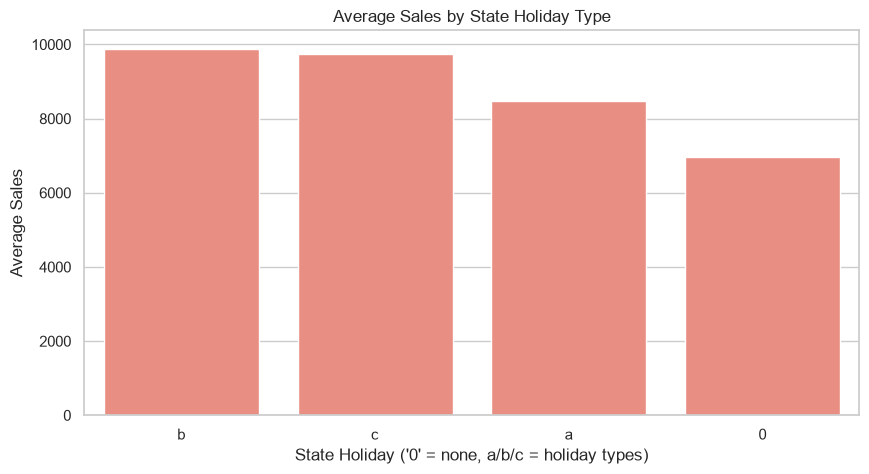

In [32]:
fig, ax = plt.subplots()
sns.barplot(data=state_hol, x="state_holiday", y="avg_sales", color="salmon", ax=ax)
ax.set_title("Average Sales by State Holiday Type")
ax.set_xlabel("State Holiday ('0' = none, a/b/c = holiday types)")
ax.set_ylabel("Average Sales")
plt.show()

Most open-day records have `state_holiday = '0'`, since
stores are usually closed on actual holidays small counts on the holiday
categories here reflect stores that stayed open regardless. On holiday days the avg sales are higher than avg sales on normal days but we can't conclude it directly as number of holiday days are very less than non holiday days.

### 5.2 School holiday effect

In [33]:
school_hol = run_query("""
SELECT
    school_holiday,
    AVG(sales) AS avg_sales,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY school_holiday;
""")
school_hol

,school_holiday,avg_sales,n_days
0,0,6896.782411,680935
1,1,7200.181650,163457


C:\Users\3366a\AppData\Local\Temp\ipykernel_21336\514166073.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No School Holiday", "School Holiday"])


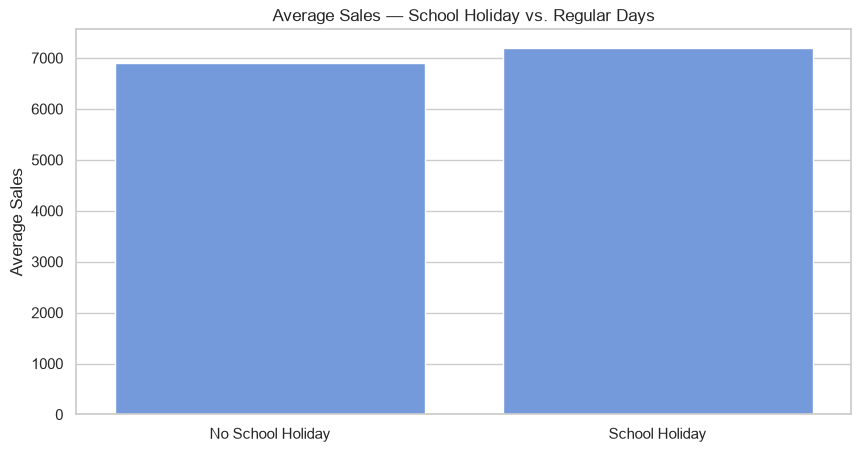

In [34]:
fig, ax = plt.subplots()
sns.barplot(data=school_hol, x="school_holiday", y="avg_sales",
            color="cornflowerblue", ax=ax)
ax.set_xticklabels(["No School Holiday", "School Holiday"])
ax.set_title("Average Sales — School Holiday vs. Regular Days")
ax.set_xlabel("")
ax.set_ylabel("Average Sales")
plt.show()

A meaningful difference here justifies
keeping `school_holiday` as a model feature rather than dropping it for being
"too similar" to state holidays though the gap is not too big but we can include it.

---

<a id="sec-6"></a>
## 6. Promotions Analysis

Quantify the sales lift from short-term (`Promo`) and long-running (`Promo2`)
promotions.

### 6.1 Promo vs. non-promo sales

In [35]:
promo_cmp = run_query("""
SELECT
    promo,
    AVG(sales) AS avg_sales,
    AVG(customers) AS avg_customers,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY promo;
""")
promo_cmp

,promo,avg_sales,avg_customers,n_days
0,0,5929.407603,696.856886,467496
1,1,8228.281239,844.434401,376896


C:\Users\3366a\AppData\Local\Temp\ipykernel_21336\523093018.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Promo", "Promo Active"])


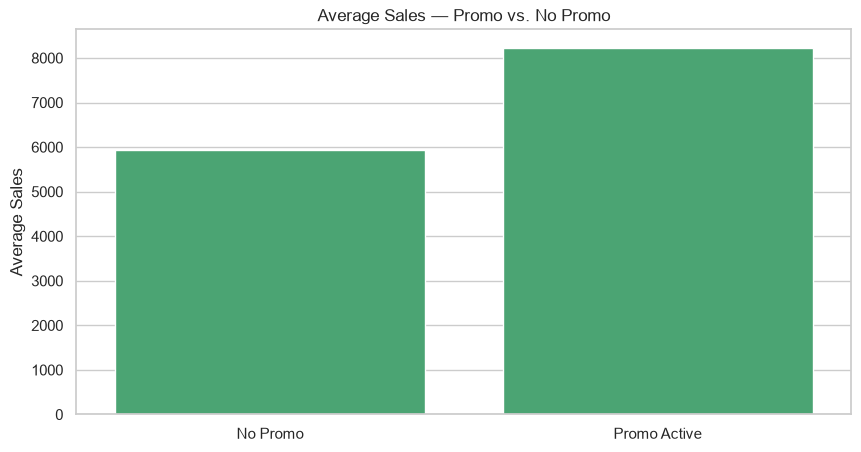

In [36]:
fig, ax = plt.subplots()
sns.barplot(data=promo_cmp, x="promo", y="avg_sales", color="mediumseagreen", ax=ax)
ax.set_xticklabels(["No Promo", "Promo Active"])
ax.set_title("Average Sales — Promo vs. No Promo")
ax.set_xlabel("")
ax.set_ylabel("Average Sales")
plt.show()

Here there is a huge difference between avg sales of No Promo vs Promo Active which tells that running Active Promo may increase sales.

### 6.2 Promo lift (single-row conditional aggregation)

In [37]:
# Same comparison as 6.1, but computed as one row using CASE WHEN instead of
run_query("""
SELECT
    AVG(CASE WHEN promo = 1 THEN sales END) AS avg_sales_promo,
    AVG(CASE WHEN promo = 0 THEN sales END) AS avg_sales_no_promo,
    AVG(CASE WHEN promo = 1 THEN sales END) - AVG(CASE WHEN promo = 0 THEN sales END) AS sales_lift,
    (AVG(CASE WHEN promo = 1 THEN sales END) - AVG(CASE WHEN promo = 0 THEN sales END))
        * 100.0 / AVG(CASE WHEN promo = 0 THEN sales END) AS pct_lift
FROM sales_daily
WHERE open = 1;
""")

,avg_sales_promo,avg_sales_no_promo,sales_lift,pct_lift
0,8228.281239,5929.407603,2298.873636,38.770714


The `pct_lift` figure here is a directly quotable business number
— e.g. *"Promotions lift average daily sales by 38.7%"* useful for the
business-impact narrative and for justifying `promo` as a high-value model
feature.

### 6.3 Promo2 (long-running promotion) effect

In [38]:
promo2_cmp = run_query("""
SELECT
    s.promo2,
    AVG(sd.sales) AS avg_sales,
    COUNT(*) AS n_days
FROM sales_daily sd
JOIN stores s ON sd.store_id = s.store_id
WHERE sd.open = 1
GROUP BY s.promo2;
""")
promo2_cmp

,promo2,avg_sales,n_days
0,0,7350.557935,423307
1,1,6558.386062,421085


C:\Users\3366a\AppData\Local\Temp\ipykernel_21336\1411647248.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Not in Promo2", "In Promo2"])


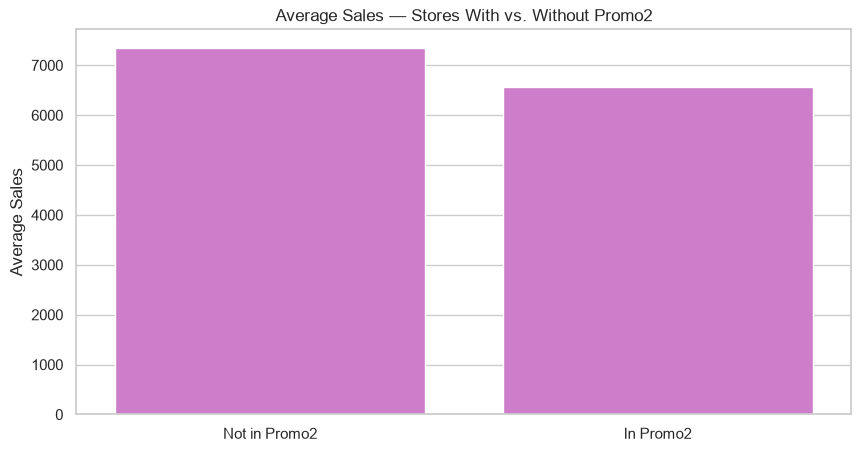

In [39]:
fig, ax = plt.subplots()
sns.barplot(data=promo2_cmp, x="promo2", y="avg_sales", color="orchid", ax=ax)
ax.set_xticklabels(["Not in Promo2", "In Promo2"])
ax.set_title("Average Sales — Stores With vs. Without Promo2")
ax.set_xlabel("")
ax.set_ylabel("Average Sales")
plt.show()

Promo2 is a store-level (not day-level) flag, so this compares
*store segments* rather than daily promo activity a weaker/different signal
than 6.1's day-level `promo` effect.

### 6.4 Stores with highest promo frequency

In [40]:
promo_freq = run_query("""
SELECT
    store_id,
    AVG(CAST(promo AS FLOAT)) AS pct_days_with_promo
FROM sales_daily
GROUP BY store_id
ORDER BY pct_days_with_promo DESC
LIMIT 10;
""")
promo_freq

,store_id,pct_days_with_promo
0,988,0.382572
1,1115,0.382166
2,1114,0.382166
3,1113,0.382166
4,1112,0.382166
5,1111,0.382166
6,1110,0.382166
7,1108,0.382166
8,1106,0.382166
9,1105,0.382166


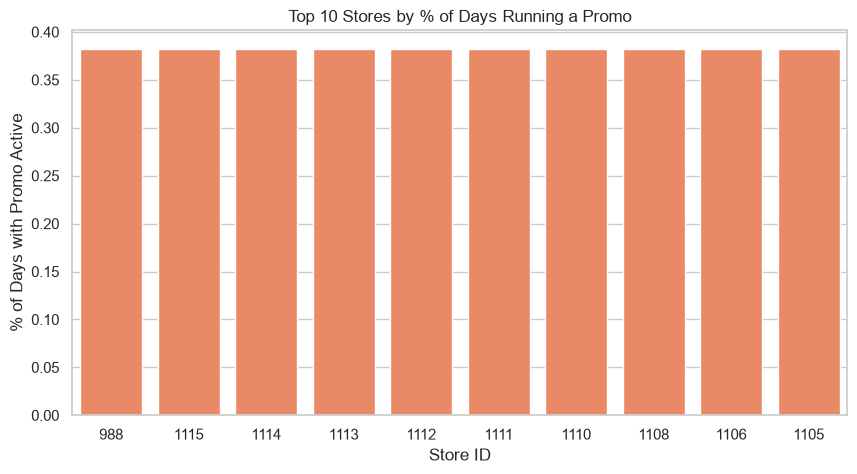

In [41]:
fig, ax = plt.subplots()
sns.barplot(data=promo_freq, x="store_id", y="pct_days_with_promo",
            order=promo_freq.sort_values("pct_days_with_promo", ascending=False)["store_id"],
            color="coral", ax=ax)
ax.set_title("Top 10 Stores by % of Days Running a Promo")
ax.set_xlabel("Store ID")
ax.set_ylabel("% of Days with Promo Active")
plt.show()

Stores that run promos very frequently may have a "diluted"
promo effect (customers expect discounts), which is worth checking against
6.1/6.2's overall lift figure when interpreting results per-store later.

---

<a id="sec-7"></a>
## 7. Store-Level Analysis

Compare performance across store types, assortments, and competitive positioning.

### 7.1 Average sales by store type & assortment

In [42]:
type_assort = run_query("""
SELECT
    s.store_type,
    s.assortment,
    AVG(sd.sales) AS avg_sales,
    COUNT(DISTINCT s.store_id) AS n_stores
FROM sales_daily sd
JOIN stores s ON sd.store_id = s.store_id
WHERE sd.open = 1
GROUP BY s.store_type, s.assortment
ORDER BY avg_sales DESC;
""")
type_assort

,store_type,assortment,avg_sales,n_stores
0,b,c,17969.556263,1
1,b,a,11133.992979,7
2,b,b,8639.346322,9
3,a,c,7573.379923,221
4,d,c,7043.363895,220
5,c,c,7037.525130,71
6,c,a,6834.931456,77
7,a,a,6537.617613,381
8,d,a,6433.619038,128


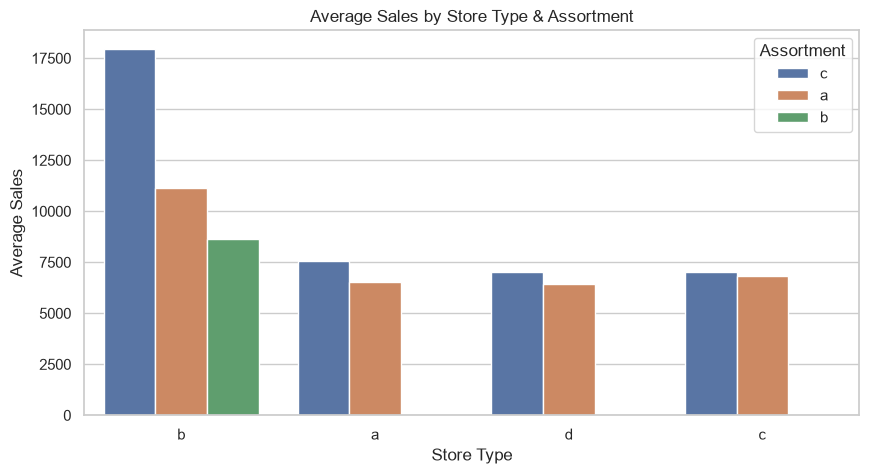

In [43]:
fig, ax = plt.subplots()
sns.barplot(data=type_assort, x="store_type", y="avg_sales", hue="assortment", ax=ax)
ax.set_title("Average Sales by Store Type & Assortment")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Sales")
ax.legend(title="Assortment")
plt.show()

### 7.2 Top 10 stores by average sales

In [44]:
top10 = run_query("""
SELECT
    store_id,
    AVG(sales) AS avg_sales,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY store_id
ORDER BY avg_sales DESC
LIMIT 10;
""")
top10

,store_id,avg_sales,n_days
0,817,21757.483418,784
1,262,20718.515924,942
2,1114,20666.562500,784
3,251,19123.068036,779
4,842,18574.795820,622
5,513,18179.089286,784
6,562,17969.556263,942
7,788,17961.914541,784
8,383,17294.716667,780
9,756,16574.816431,779


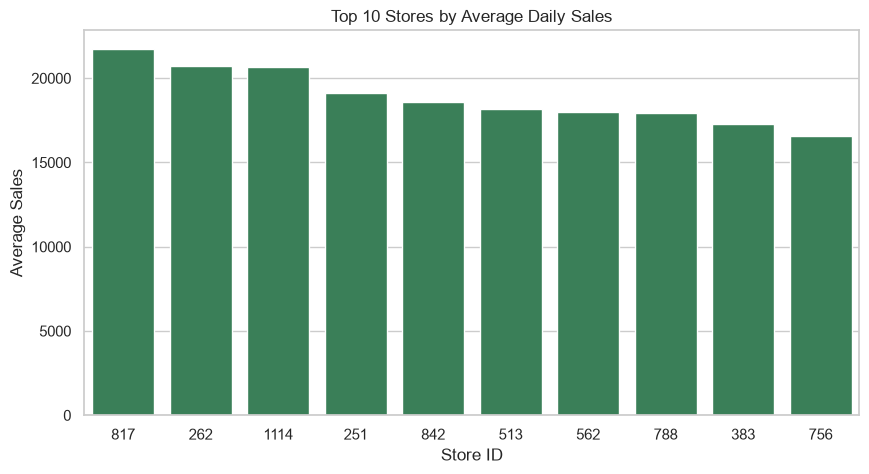

In [45]:
fig, ax = plt.subplots()
sns.barplot(data=top10, x="store_id", y="avg_sales",
            order=top10.sort_values("avg_sales", ascending=False)["store_id"],
            color="seagreen", ax=ax)
ax.set_title("Top 10 Stores by Average Daily Sales")
ax.set_xlabel("Store ID")
ax.set_ylabel("Average Sales")
plt.show()

### 7.3 Bottom 10 stores by average sales

In [46]:
bottom10 = run_query("""
SELECT
    store_id,
    AVG(sales) AS avg_sales,
    COUNT(*) AS n_days
FROM sales_daily
WHERE open = 1
GROUP BY store_id
ORDER BY avg_sales ASC
LIMIT 10;
""")
bottom10

,store_id,avg_sales,n_days
0,307,2703.736573,782
1,543,2790.380282,781
2,198,2900.604859,782
3,208,2936.290816,784
4,841,2972.608974,780
5,254,3005.983312,779
6,794,3083.812821,780
7,219,3133.712452,779
8,210,3193.984596,779
9,425,3237.659794,776


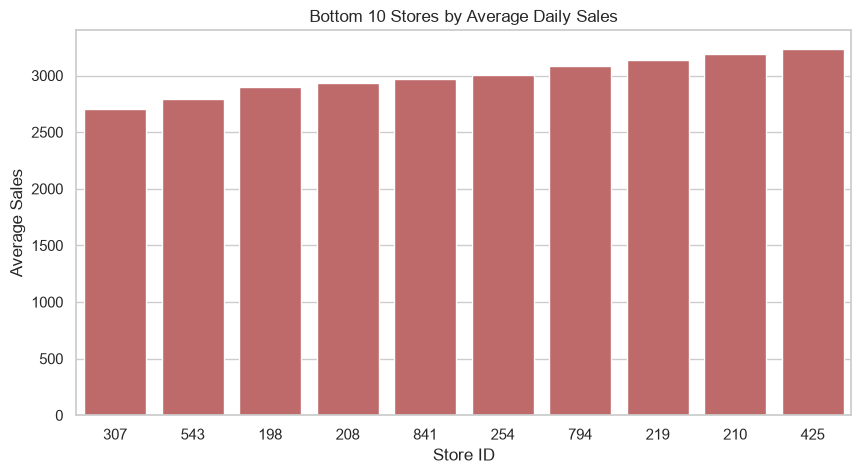

In [47]:
fig, ax = plt.subplots()
sns.barplot(data=bottom10, x="store_id", y="avg_sales",
            order=bottom10.sort_values("avg_sales")["store_id"],
            color="indianred", ax=ax)
ax.set_title("Bottom 10 Stores by Average Daily Sales")
ax.set_xlabel("Store ID")
ax.set_ylabel("Average Sales")
plt.show()

The gap between top and bottom performers here sets expectations
for how much per-store variance the model needs to capture — a huge spread
argues for store-level (or store-cluster-level) features/normalization rather
than a single unscaled global model.

### 7.4 Store count per type/assortment combination

In [48]:
# Class balance check — useful before deciding whether to cluster stores by
# type/assortment for modeling (some combinations may have very few stores).
store_counts = run_query("""
SELECT
    store_type,
    assortment,
    COUNT(*) AS n_stores
FROM stores
GROUP BY store_type, assortment
ORDER BY store_type, assortment;
""")
store_counts

,store_type,assortment,n_stores
0,a,a,381
1,a,c,221
2,b,a,7
3,b,b,9
4,b,c,1
5,c,a,77
6,c,c,71
7,d,a,128
8,d,c,220


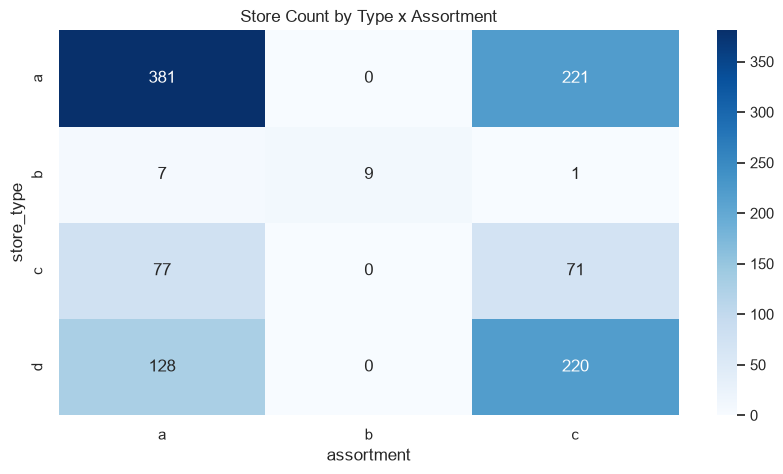

In [49]:
pivot = store_counts.pivot(index="store_type", columns="assortment", values="n_stores").fillna(0)

fig, ax = plt.subplots()
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Store Count by Type x Assortment")
plt.show()

### 7.5 Sales by competition distance

In [50]:
comp_dist = run_query("""
SELECT
    CASE
        WHEN s.competition_distance < 1000 THEN 'Under 1km'
        WHEN s.competition_distance < 5000 THEN '1-5km'
        WHEN s.competition_distance < 20000 THEN '5-20km'
        ELSE 'Over 20km'
    END AS distance_bucket,
    AVG(sd.sales) AS avg_sales,
    COUNT(DISTINCT s.store_id) AS n_stores
FROM sales_daily sd
JOIN stores s ON sd.store_id = s.store_id
WHERE sd.open = 1 AND s.competition_distance IS NOT NULL
GROUP BY distance_bucket
ORDER BY avg_sales DESC;
""")
comp_dist

,distance_bucket,avg_sales,n_stores
0,Under 1km,7309.679305,328
1,Over 20km,7026.720824,57
2,1-5km,6828.970815,434
3,5-20km,6743.295754,293


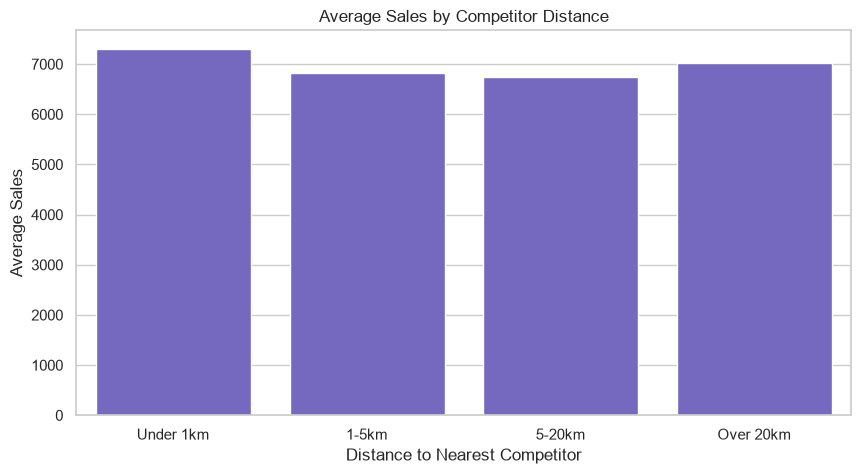

In [51]:
order = ["Under 1km", "1-5km", "5-20km", "Over 20km"]

fig, ax = plt.subplots()
sns.barplot(data=comp_dist, x="distance_bucket", y="avg_sales", order=order,
            color="slateblue", ax=ax)
ax.set_title("Average Sales by Competitor Distance")
ax.set_xlabel("Distance to Nearest Competitor")
ax.set_ylabel("Average Sales")
plt.show()

Somewhat counter-intuitively, stores with *closer* competition
sometimes show higher sales in this dataset — often because close competitors
cluster in high-footfall urban areas. Worth noting as a caveat rather than
assuming distance alone drives sales.

---

<a id="sec-8"></a>
## 8. Store Closures & Anomalies

Look for systematic closure patterns (e.g. Sundays) and any stores with unusually
long closures (e.g. renovations) that may need special handling.

### 8.1 Stores closed per date (over time)

In [52]:
closures_over_time = run_query("""
SELECT
    date,
    SUM(CASE WHEN open = 0 THEN 1 ELSE 0 END) AS stores_closed,
    COUNT(*) AS total_stores_recorded
FROM sales_daily
GROUP BY date
ORDER BY date;
""")
closures_over_time.head(10)


,date,stores_closed,total_stores_recorded
0,2013-01-01 00:00:00.000000,1097,1114
1,2013-01-02 00:00:00.000000,4,1115
2,2013-01-03 00:00:00.000000,6,1115
3,2013-01-04 00:00:00.000000,7,1115
4,2013-01-05 00:00:00.000000,8,1115
5,2013-01-06 00:00:00.000000,1096,1115
6,2013-01-07 00:00:00.000000,9,1115
7,2013-01-08 00:00:00.000000,10,1115
8,2013-01-09 00:00:00.000000,10,1115
9,2013-01-10 00:00:00.000000,10,1115


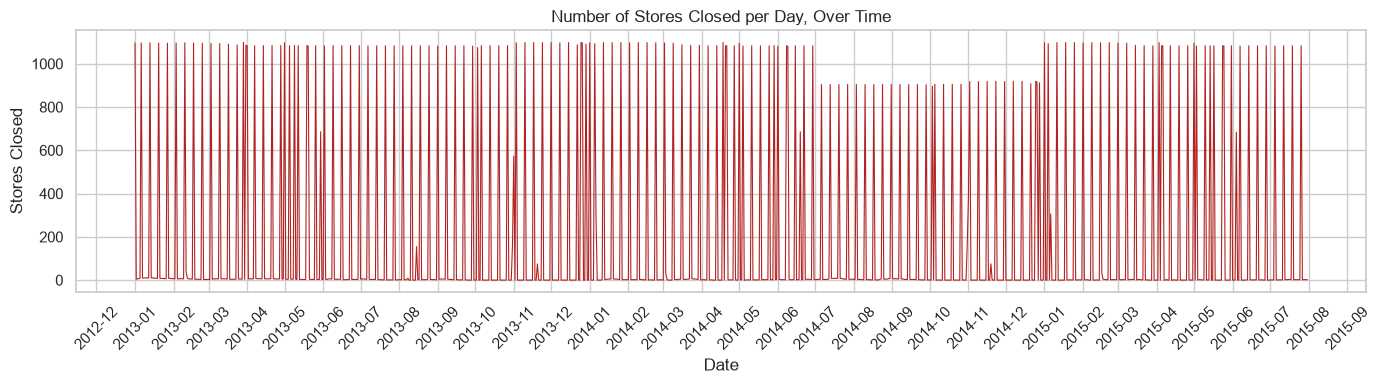

In [53]:
closures_over_time["date"] = pd.to_datetime(closures_over_time["date"]) 

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(closures_over_time["date"], closures_over_time["stores_closed"],
        color="firebrick", linewidth=0.8)
ax.set_title("Number of Stores Closed per Day, Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Stores Closed")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A regular weekly spike pattern (most stores close on
Sundays). From 2014-06 to 2015-01 the number of stores closed are less than the other dates may be due to the dataset has less record of stores between these dates.

In [54]:
closures_over_time = run_query("""
SELECT
    date,
    SUM(CASE WHEN open = 0 THEN 1 ELSE 0 END) AS stores_closed,
    COUNT(*) AS total_stores_recorded
FROM sales_daily
WHERE date BETWEEN "2014-09-01 00:00:00.000000" AND "2015-01-01 00:00:00.000000"
GROUP BY date
ORDER BY date;
""")
closures_over_time.head(10)

,date,stores_closed,total_stores_recorded
0,2014-09-01 00:00:00.000000,7,935
1,2014-09-02 00:00:00.000000,6,935
2,2014-09-03 00:00:00.000000,6,935
3,2014-09-04 00:00:00.000000,7,935
4,2014-09-05 00:00:00.000000,5,935
5,2014-09-06 00:00:00.000000,5,935
6,2014-09-07 00:00:00.000000,904,935
7,2014-09-08 00:00:00.000000,5,935
8,2014-09-09 00:00:00.000000,6,935
9,2014-09-10 00:00:00.000000,4,935


This confirms that the dataset has less record between the dates 2014-06 to 2015-01

### 8.2 Stores with the most total closed days

In [55]:
# Common Table Expression (CTE): compute closed-day counts per store once,
# then filter/sort/limit on top of it — cleaner than a nested subquery.
most_closed = run_query("""
WITH closure_counts AS (
    SELECT
        store_id,
        COUNT(*) AS closed_days
    FROM sales_daily
    WHERE open = 0
    GROUP BY store_id
)
SELECT *
FROM closure_counts
ORDER BY closed_days DESC
LIMIT 10;
""")
most_closed

,store_id,closed_days
0,103,311
1,708,254
2,349,242
3,972,240
4,674,196
5,560,195
6,837,191
7,25,190
8,105,188
9,969,187


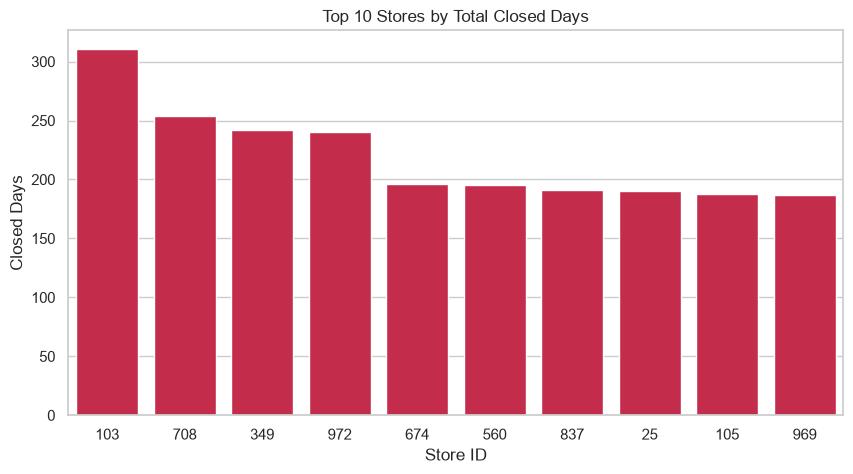

In [56]:
fig, ax = plt.subplots()
sns.barplot(data=most_closed, x="store_id", y="closed_days",
            order=most_closed.sort_values("closed_days", ascending=False)["store_id"],
            color="crimson", ax=ax)
ax.set_title("Top 10 Stores by Total Closed Days")
ax.set_xlabel("Store ID")
ax.set_ylabel("Closed Days")
plt.show()

Any store far above the rest here likely had an extended
renovation/closure period a good candidate to exclude from per-store SARIMA
fitting (too many missing days to model reliably) or to flag explicitly as a
feature.

### 8.3 Stores with zero closures (sanity/edge case)

In [57]:
zero_closures = run_query("""
WITH closure_counts AS (
    SELECT
        store_id,
        SUM(CASE WHEN open = 0 THEN 1 ELSE 0 END) AS closed_days
    FROM sales_daily
    GROUP BY store_id
)
SELECT *
FROM closure_counts
WHERE closed_days = 0
ORDER BY store_id;
""")
zero_closures

,store_id,closed_days
0,85,0
1,262,0
2,335,0
3,423,0
4,494,0
5,562,0
6,682,0
7,733,0
8,769,0
9,1097,0


Stores here were never recorded as closed for the entire date
range worth a quick manual check that this is genuine (e.g. a 7-day-a-week
store) rather than a data logging gap.


<a id="sec-9"></a>
## 9. Feature Preview & Correlation

Pull the joined `sales_daily` + `stores` feature set that feature engineering will
build on, and check correlations between numeric fields.

### 9.1 Joined feature set

In [58]:
# The full feature-relevant join — sales_daily's daily fields plus stores'
# static metadata. This becomes the base table for 02_feature_engineering.ipynb.
features = run_query("""
SELECT
    sd.store_id,
    sd.date,
    sd.day_of_week,
    sd.sales,
    sd.customers,
    sd.promo,
    sd.state_holiday,
    sd.school_holiday,
    s.store_type,
    s.assortment,
    s.competition_distance,
    s.promo2
FROM sales_daily sd
JOIN stores s ON sd.store_id = s.store_id
WHERE sd.open = 1;
""")
features.head()

,store_id,date,day_of_week,sales,customers,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,promo2
0,1,2015-07-31 00:00:00.000000,5,5263,555,1,0,1,c,a,1270.0,0
1,2,2015-07-31 00:00:00.000000,5,6064,625,1,0,1,a,a,570.0,1
2,3,2015-07-31 00:00:00.000000,5,8314,821,1,0,1,a,a,14130.0,1
3,4,2015-07-31 00:00:00.000000,5,13995,1498,1,0,1,c,c,620.0,0
4,5,2015-07-31 00:00:00.000000,5,4822,559,1,0,1,a,a,29910.0,0


### 9.2 Correlation heatmap

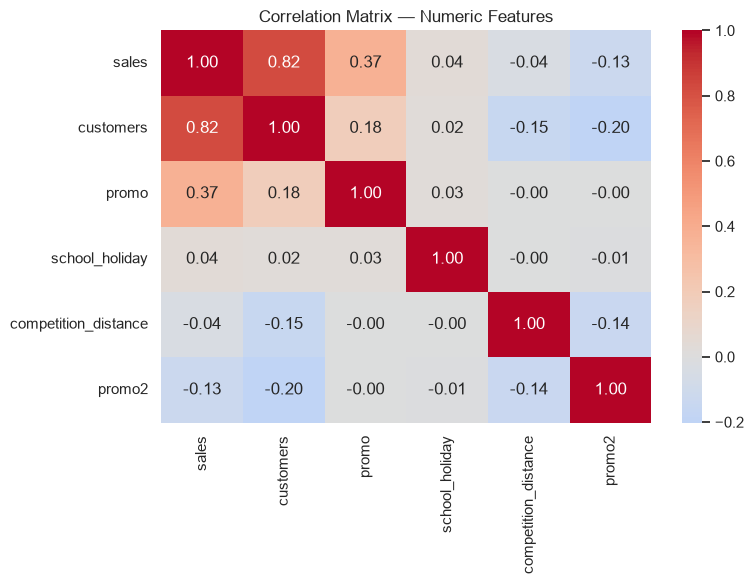

In [59]:
# Correlation heatmaps aren't a SQL-native output, so this step is done in
# pandas on the query result above rather than in the database.
numeric_cols = ["sales", "customers", "promo", "school_holiday",
                 "competition_distance", "promo2"]
corr = features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

`customers` shows the strongest correlation with `sales`
by far. Any unexpectedly strong correlations between predictor
variables themselves (multicollinearity) that will inform which features to
drop or combine during feature engineering.

---

<a id="sec-10"></a>
### Feature engineering ideas for `02_feature_engineering.ipynb`
- Lag features (1-day, 7-day) per store, built on the `LAG()` pattern from Section 4.4
- Rolling mean/std (7-day, 30-day), built on the window-function pattern from Section 4.3
- Calendar features: day-of-week, month, is-weekend, is-holiday flags
- Days-since-competition-opened (derived from `competition_open_since_month/year`)
- Store-cluster label (from Section 7.1's store type × assortment groupings) as a categorical feature